# scDeoxys PBMC 3k 教程

本 notebook 使用经典的 PBMC 3k 数据集演示 scDeoxys 在真实单细胞数据上的完整工作流程：

1. 数据加载与预处理
2. 高变基因筛选
3. ParetoVAE 模型训练
4. Simplex 潜空间编码
5. 可视化与解释

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import scanpy as sc
import anndata as ad

from scdeoxys import ParetoVAE, Trainer
from scdeoxys.plotting import (
    plot_simplex_projection,
    plot_training_curves,
    plot_umap_weights,
    plot_archetype_heatmap,
)

np.random.seed(42)
torch.manual_seed(42)

sc.settings.verbosity = 1
sc.settings.set_figure_params(dpi=100, frameon=False)

## 1. 加载 PBMC 3k 数据

In [2]:
adata = sc.datasets.pbmc3k_processed()
print(adata)

AnnData object with n_obs × n_vars = 2638 × 1838
    obs: 'n_genes', 'percent_mito', 'n_counts', 'louvain'
    var: 'n_cells'
    uns: 'draw_graph', 'louvain', 'louvain_colors', 'neighbors', 'pca', 'rank_genes_groups'
    obsm: 'X_pca', 'X_tsne', 'X_umap', 'X_draw_graph_fr'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'


## 2. 预处理

scDeoxys 需要 `adata.layers["counts"]` 中存放原始计数矩阵。

`pbmc3k_processed` 已经过 log-normalize，`.raw` 中保存了归一化前的数据。
我们从 `.raw` 恢复原始计数（取整近似），并筛选高变基因。

In [3]:
# 从 .raw 恢复数据并取整作为近似原始计数
adata_raw = adata.raw.to_adata()
adata_raw.obs = adata.obs.copy()

# .raw.X 是归一化后的数据，取整近似为计数
from scipy import sparse
if sparse.issparse(adata_raw.X):
    counts = np.round(adata_raw.X.toarray()).astype(np.float32)
else:
    counts = np.round(adata_raw.X).astype(np.float32)
counts[counts < 0] = 0

adata_raw.layers["counts"] = counts
print(f"恢复计数矩阵: {counts.shape}")
print(f"非零比例: {(counts > 0).sum() / counts.size * 100:.1f}%")
print(f"每细胞平均计数: {counts.sum(axis=1).mean():.0f}")

恢复计数矩阵: (2638, 13714)
非零比例: 6.2%
每细胞平均计数: 1013


In [4]:
# 筛选高变基因（在已有 HVG 标注的基础上，或重新计算）
sc.pp.highly_variable_genes(adata_raw, n_top_genes=2000, flavor="seurat_v3", layer="counts")
adata_hvg = adata_raw[:, adata_raw.var["highly_variable"]].copy()

# 确保 counts layer 存在
if sparse.issparse(adata_hvg.layers["counts"]):
    adata_hvg.layers["counts"] = adata_hvg.layers["counts"].toarray()

print(f"筛选后: {adata_hvg.shape[0]} 细胞, {adata_hvg.shape[1]} 高变基因")
print(adata_hvg)

筛选后: 2638 细胞, 2000 高变基因
AnnData object with n_obs × n_vars = 2638 × 2000
    obs: 'n_genes', 'percent_mito', 'n_counts', 'louvain'
    var: 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'draw_graph', 'louvain', 'louvain_colors', 'neighbors', 'pca', 'rank_genes_groups', 'hvg'
    obsm: 'X_pca', 'X_tsne', 'X_umap', 'X_draw_graph_fr'
    layers: 'counts'
    obsp: 'distances', 'connectivities'


## 3. 训练 ParetoVAE

PBMC 数据通常包含 7-8 种主要细胞类型，我们设置 `n_archetypes=8`。

In [5]:
n_archetypes = 8

model = ParetoVAE(
    n_genes=adata_hvg.shape[1],
    n_archetypes=n_archetypes,
    hidden_dims=[512, 256, 128],
    decoder_dropout=0.3,
)

trainer = Trainer(
    model,
    learning_rate=1e-3,
    beta_warmup_epochs=100,
    beta_min=0.0,
    beta_max=1.0,
    free_bits=1.0,
    n_cycles=4,
    annealing_type="cyclical",
)

total_params = sum(p.numel() for p in model.parameters())
print(f"模型参数量: {total_params:,}")
print(f"Archetypes: {n_archetypes}")
print(f"设备: {trainer.device}")
print(f"退火策略: {trainer.annealing_type}, {trainer.n_cycles} cycles")
print(f"Free bits: {trainer.free_bits}")

模型参数量: 2,388,144
Archetypes: 8
设备: cpu
退火策略: cyclical, 4 cycles
Free bits: 1.0


In [6]:
history = trainer.train(
    adata_hvg,
    n_epochs=500,
    batch_size=128,
    verbose=True,
)

print(f"\n最终损失 — total: {history['total_loss'][-1]:.2f}, "
      f"recon: {history['recon_loss'][-1]:.2f}, "
      f"kl: {history['kl_loss'][-1]:.2f}")

Training: 100%|██████████| 500/500 [03:50<00:00,  2.17it/s, loss=2537.6255, recon=536.6468, kl=8.0039, beta=1.00]


最终损失 — total: 2537.63, recon: 536.65, kl: 8.00


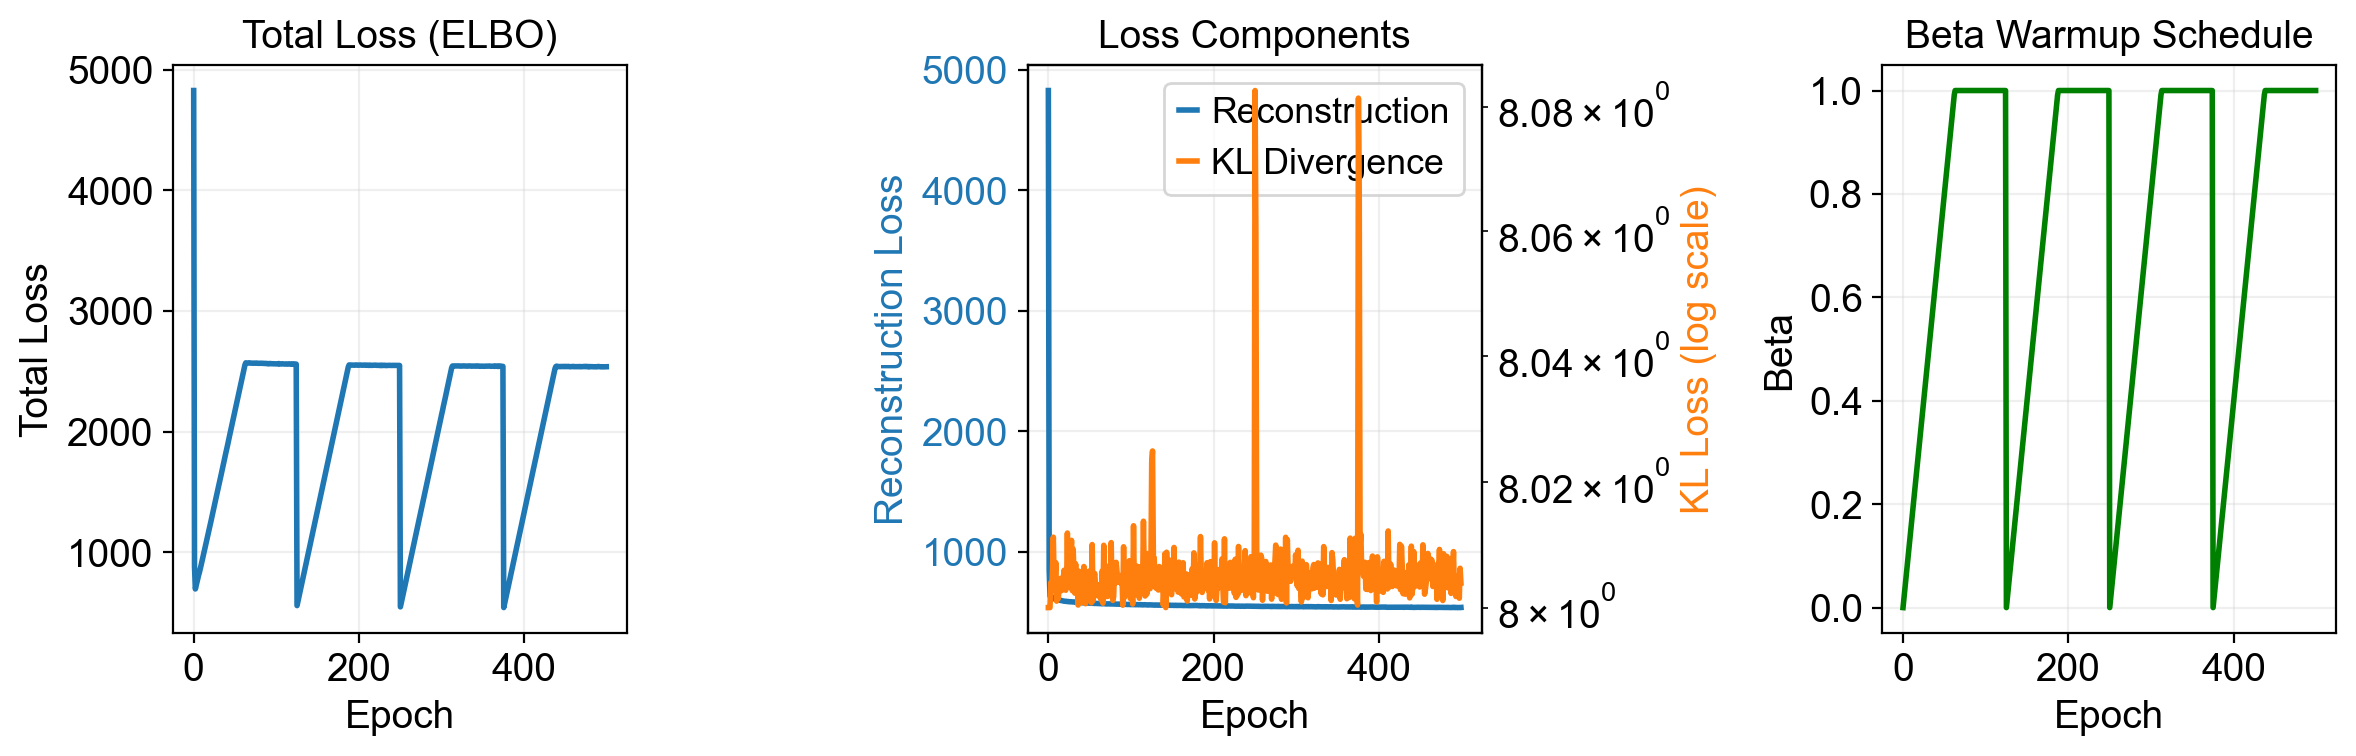

In [7]:
plot_training_curves(adata_hvg)
plt.show()

## 4. 编码到 Simplex 空间

In [8]:
trainer.encode(adata_hvg)
z = adata_hvg.obsm["X_scdeoxys"]

print(f"Simplex 坐标形状: {z.shape}")
print(f"行和范围: [{z.sum(axis=1).min():.4f}, {z.sum(axis=1).max():.4f}]")
print(f"每个 archetype 的平均权重:")
for i in range(n_archetypes):
    print(f"  Archetype {i}: {z[:, i].mean():.4f}")

Simplex 坐标形状: (2638, 8)
行和范围: [1.0000, 1.0000]
每个 archetype 的平均权重:
  Archetype 0: 0.1255
  Archetype 1: 0.1157
  Archetype 2: 0.1311
  Archetype 3: 0.1237
  Archetype 4: 0.1205
  Archetype 5: 0.1193
  Archetype 6: 0.1332
  Archetype 7: 0.1310


## 5. 可视化

### 5.1 Simplex 投影（RadViz）

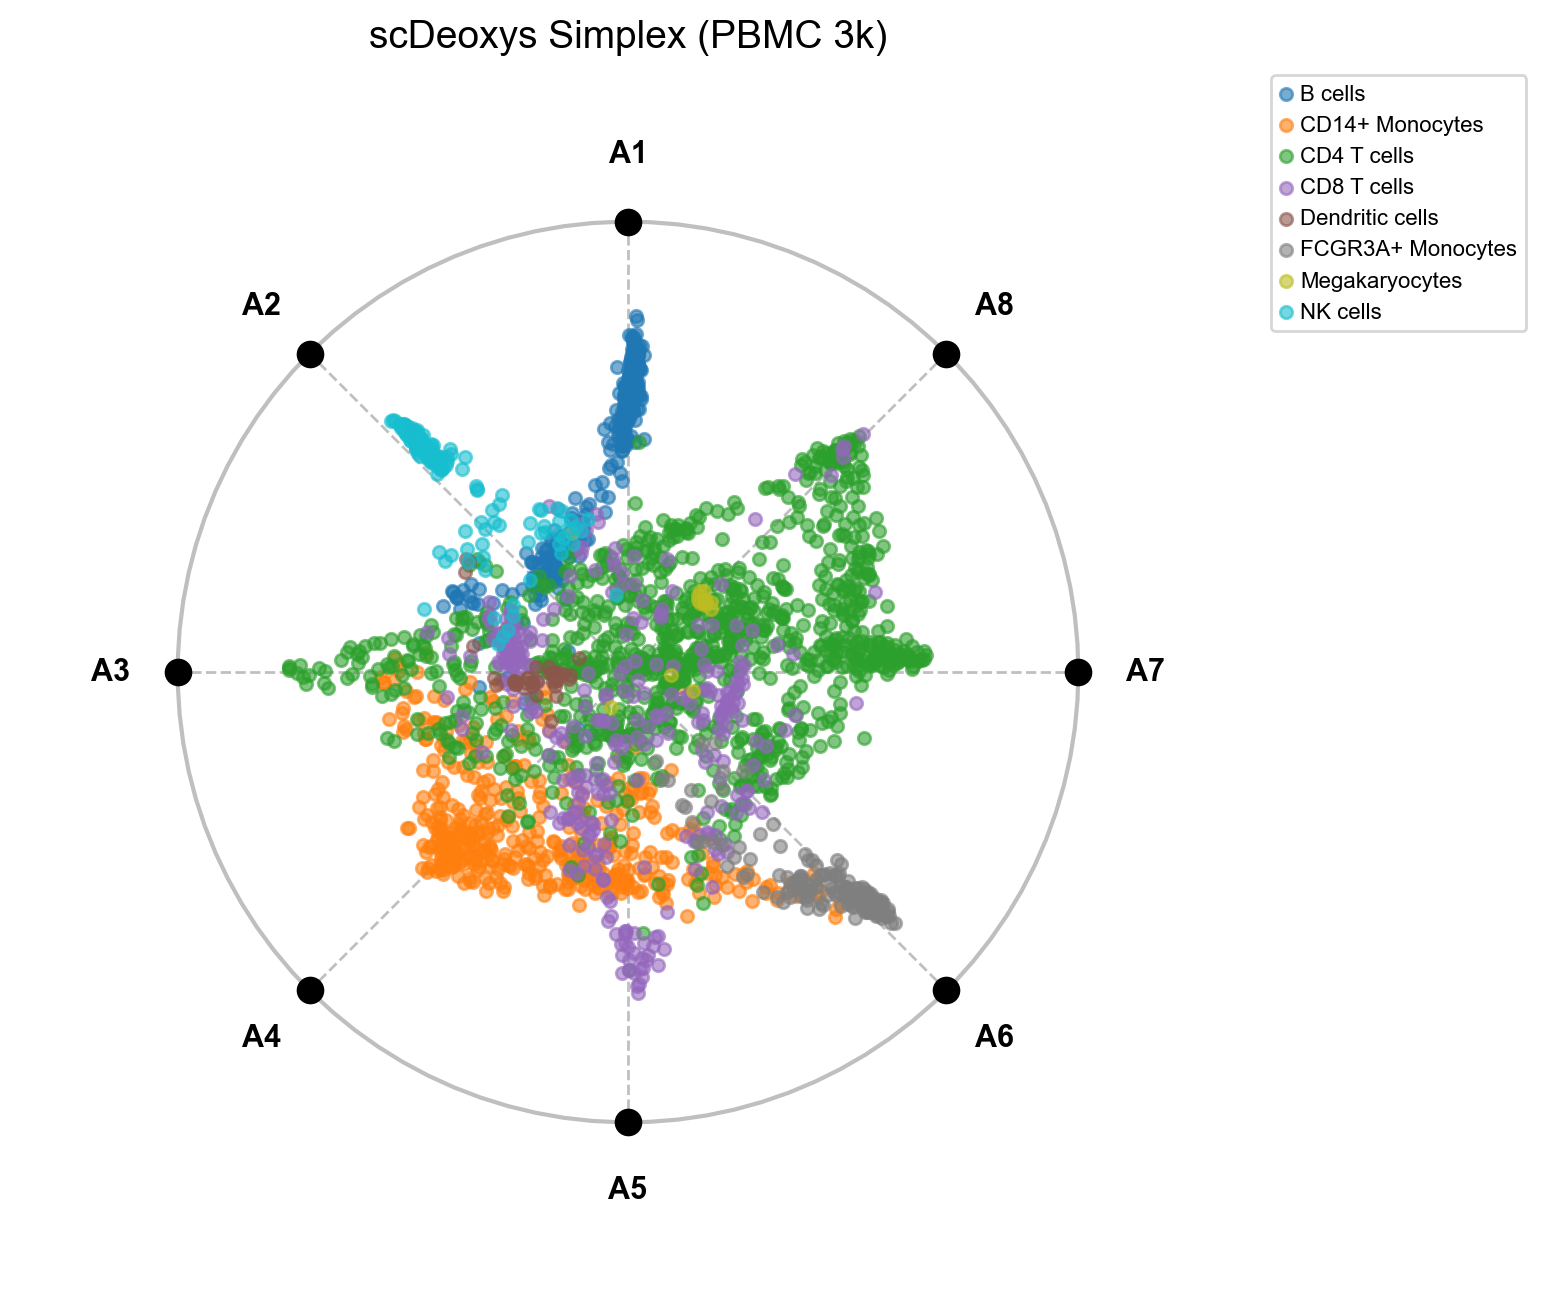

In [9]:
cell_types = np.asarray(adata_hvg.obs["louvain"])

fig, ax = plt.subplots(figsize=(8, 8))
plot_simplex_projection(z, labels=cell_types, ax=ax, title="scDeoxys Simplex (PBMC 3k)")
plt.show()

### 5.2 UMAP of Archetype Weights

/Users/liangxian/miniforge3/envs/scDeoxys/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/liangxian/miniforge3/envs/scDeoxys/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


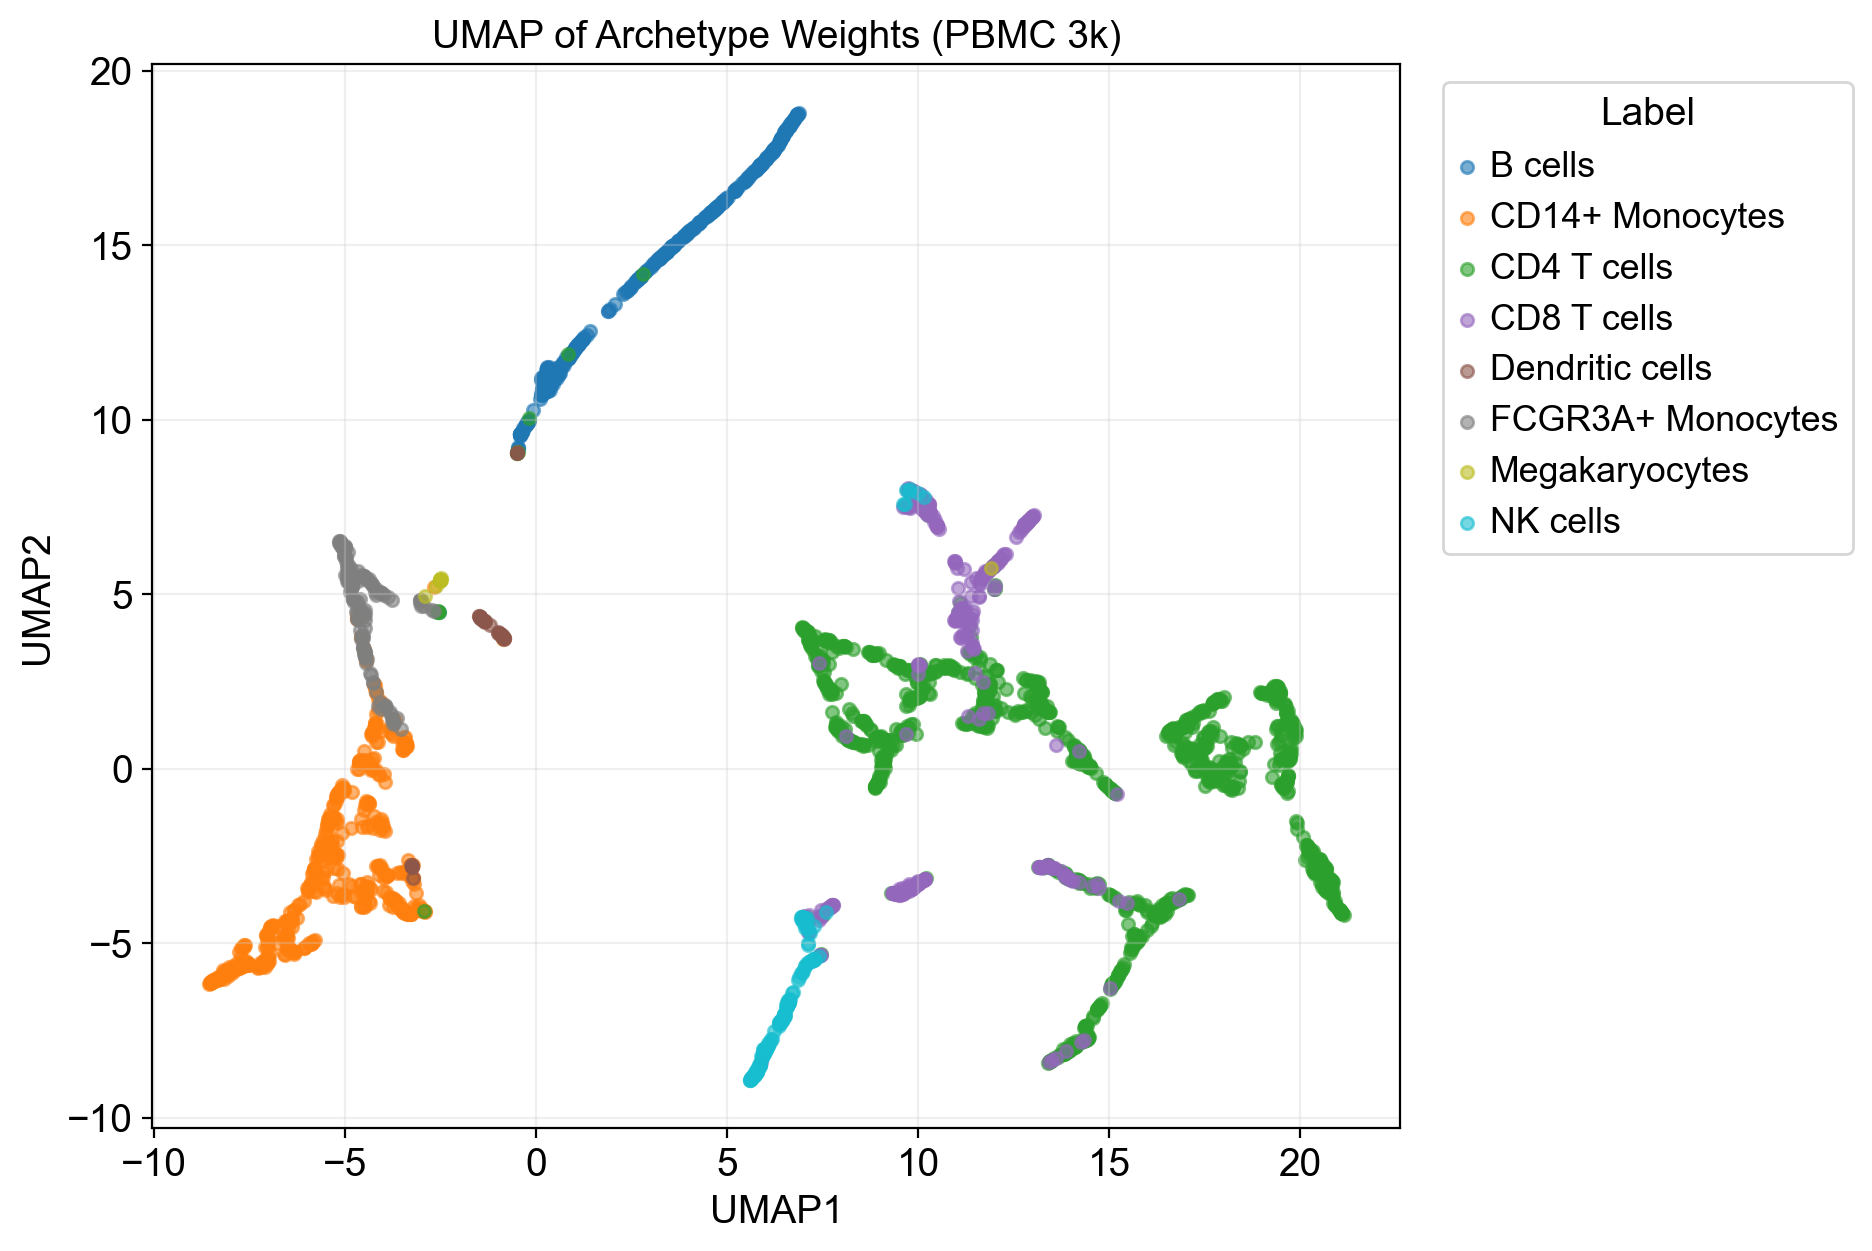

In [10]:
fig, umap_coords = plot_umap_weights(
    z, labels=cell_types, color_by_dominant=False,
    title="UMAP of Archetype Weights (PBMC 3k)",
)
plt.show()

### 5.3 Archetype Heatmap

/Users/liangxian/project/scDeoxys/scdeoxys/plotting/simplex.py:580: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


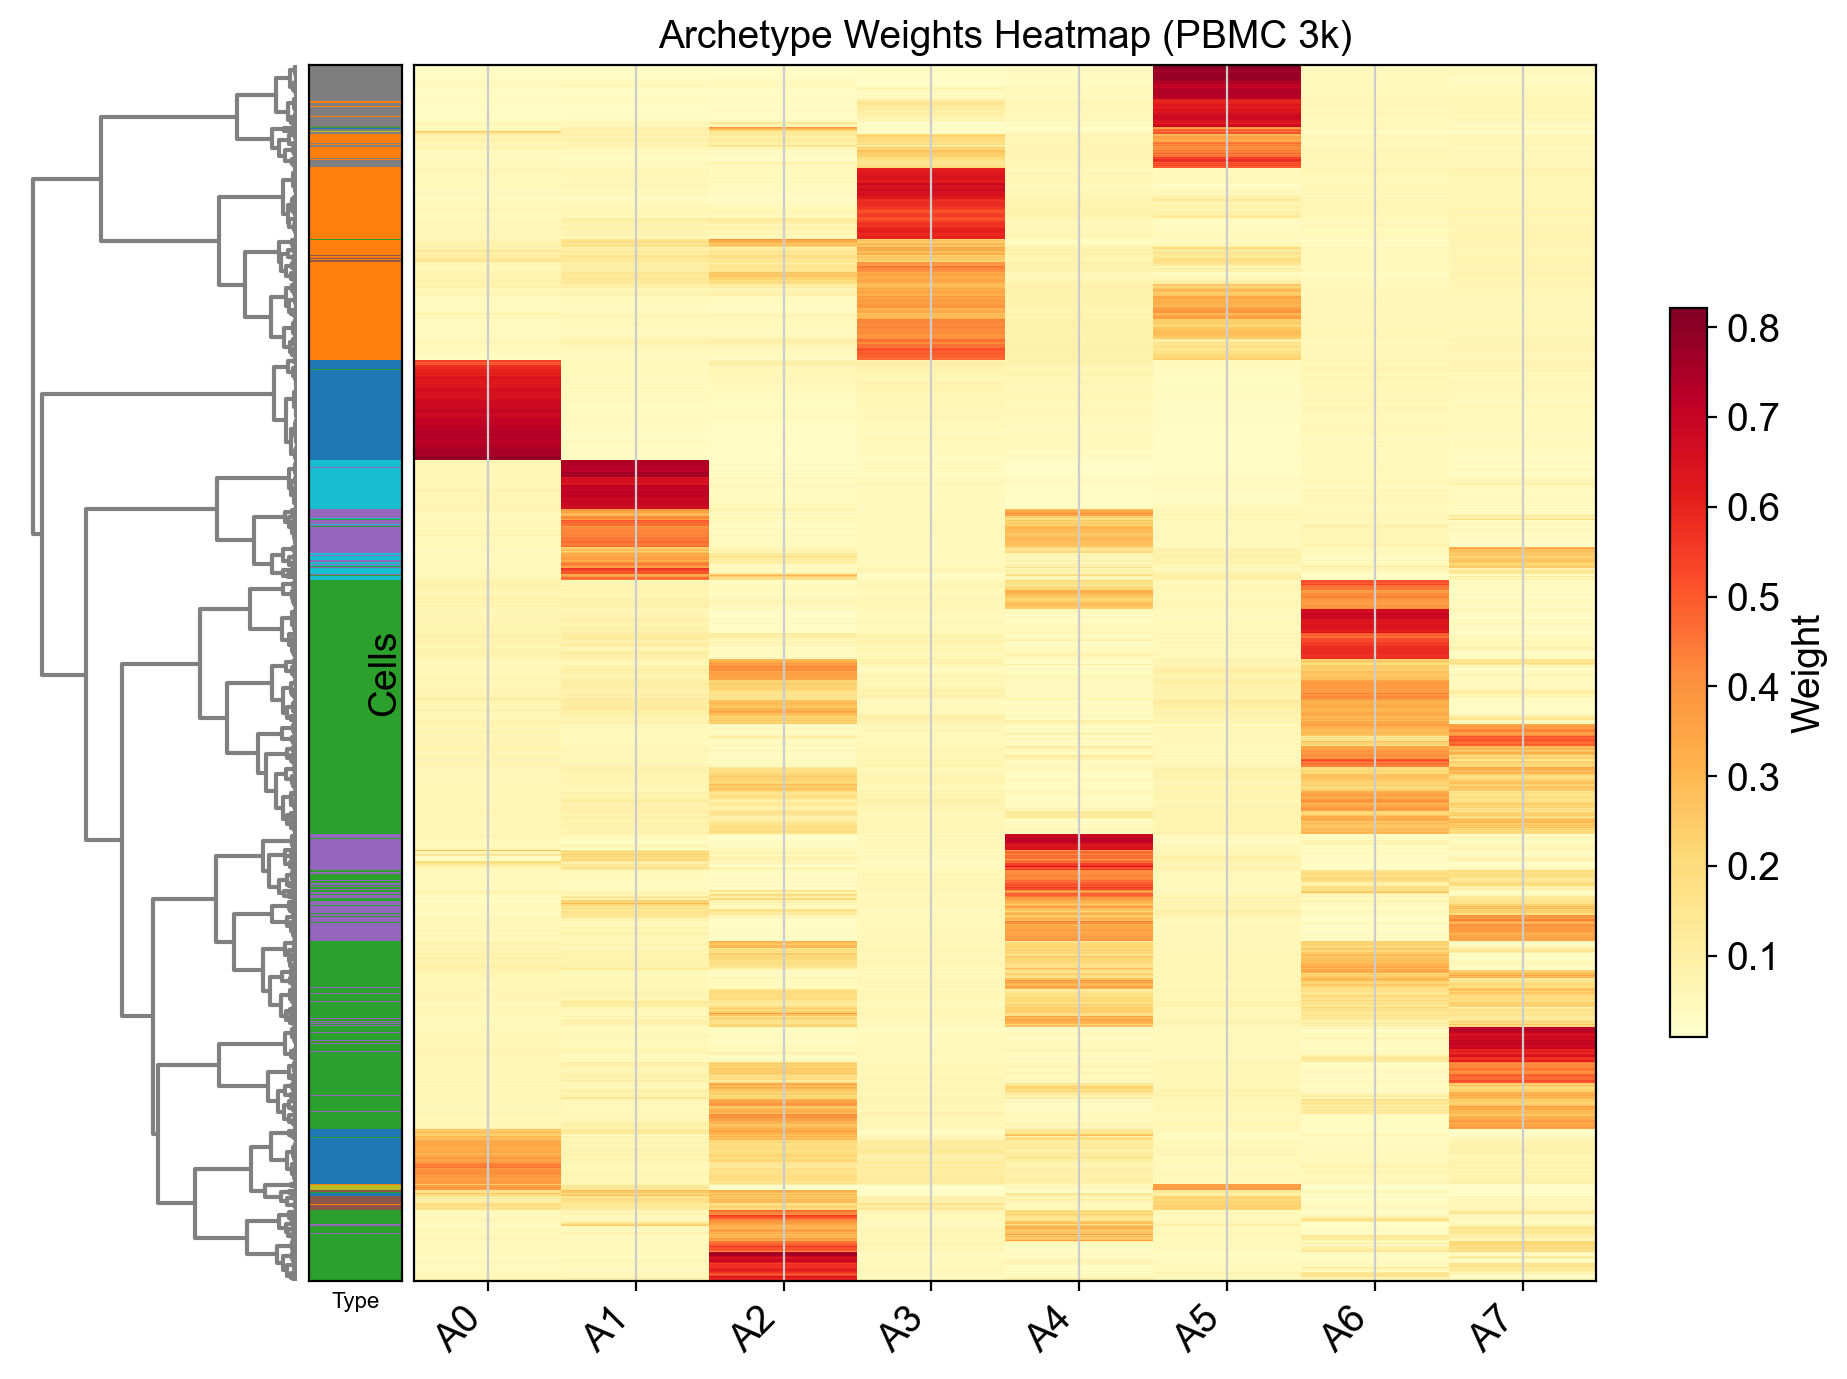

In [11]:
fig, cell_order = plot_archetype_heatmap(
    z,
    cell_labels=cell_types,
    archetype_names=[f"A{i}" for i in range(n_archetypes)],
    figsize=(12, 8),
    title="Archetype Weights Heatmap (PBMC 3k)",
)
plt.show()

### 5.4 与 Scanpy UMAP 对比

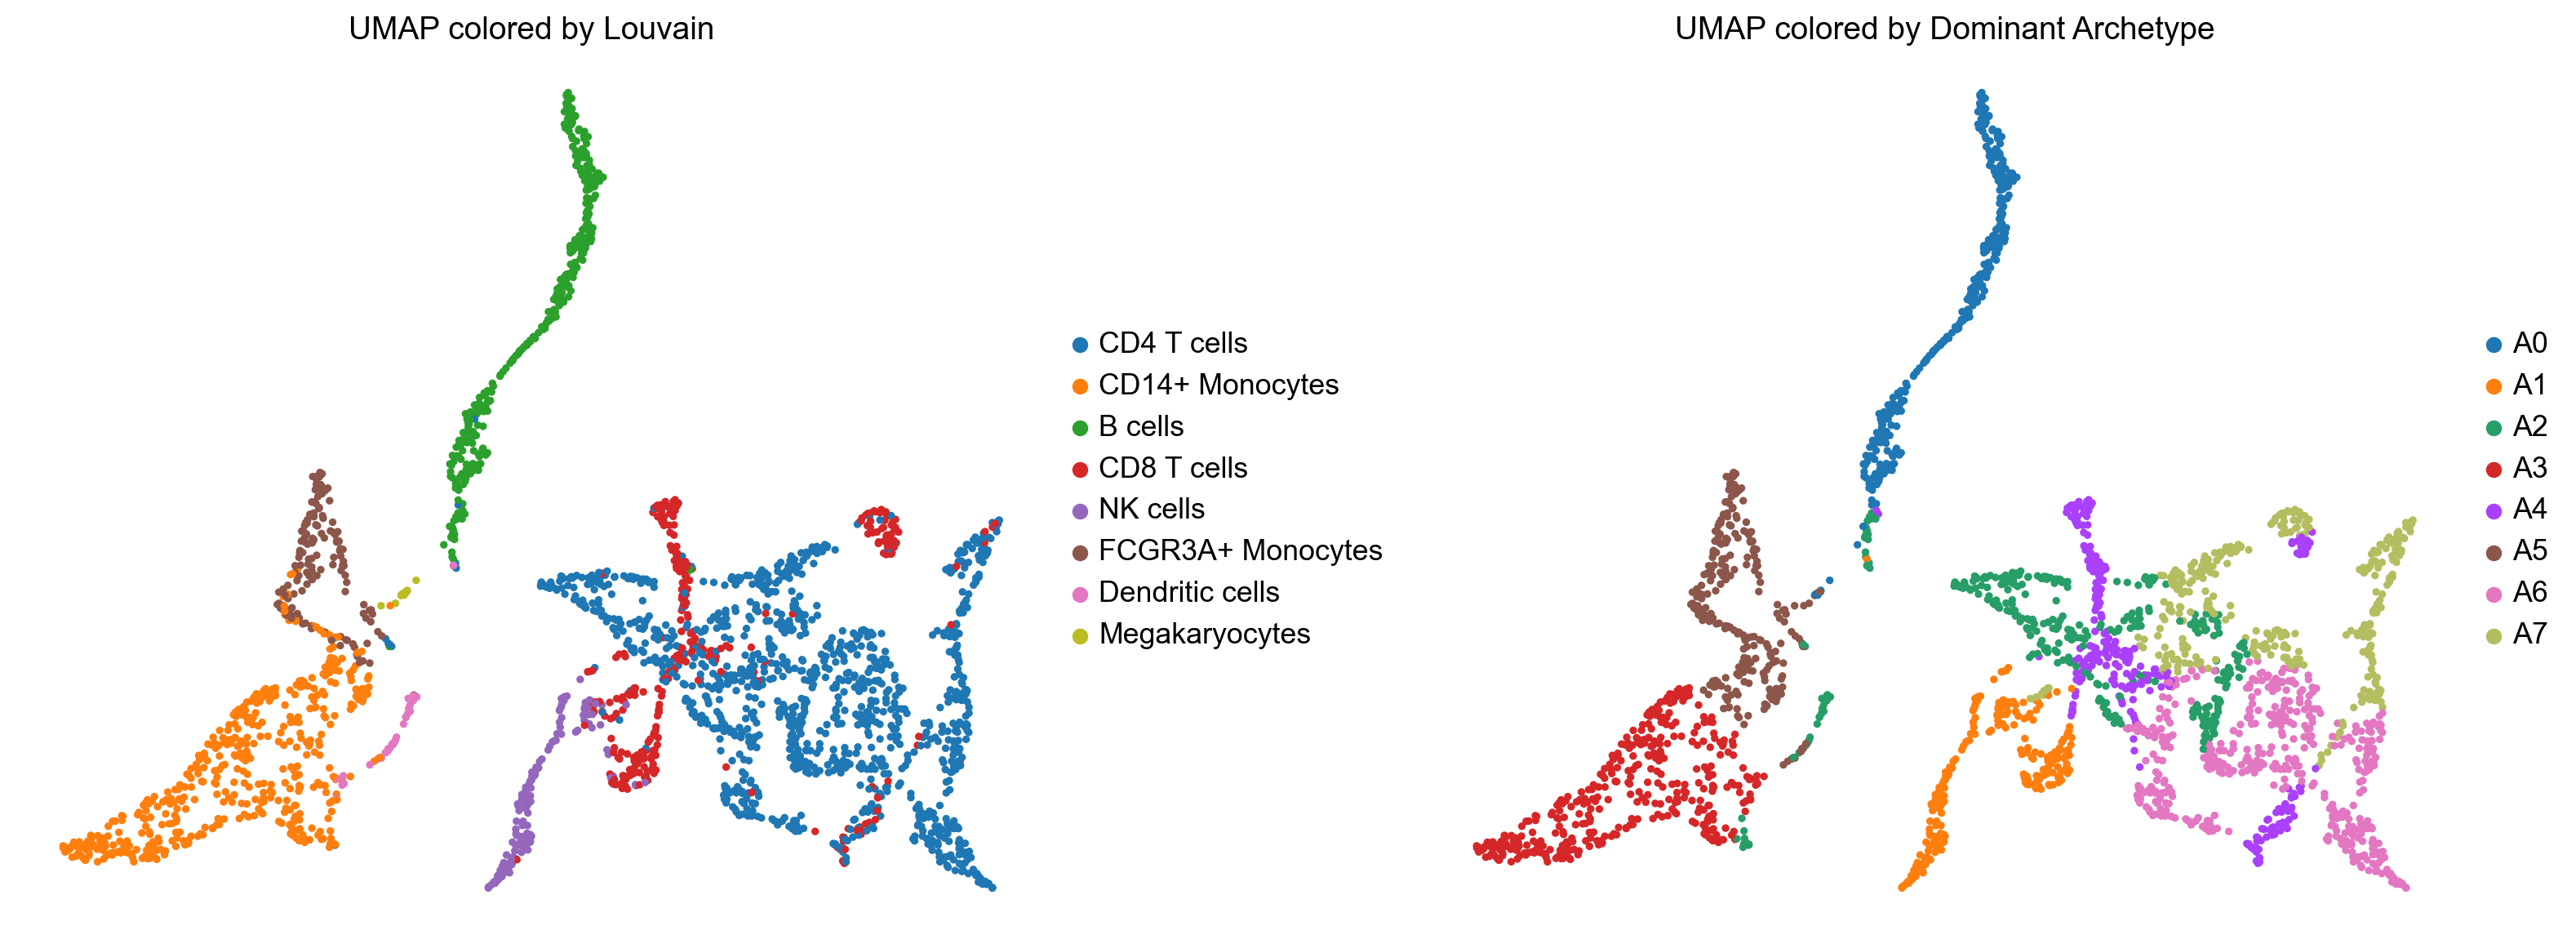

In [12]:
# 用 dominant archetype 给原始 UMAP 着色
dominant = np.argmax(z, axis=1)
adata_hvg.obs["dominant_archetype"] = [f"A{d}" for d in dominant]

# 计算 UMAP（基于 scDeoxys simplex 坐标）
sc.pp.neighbors(adata_hvg, use_rep="X_scdeoxys", n_neighbors=15)
sc.tl.umap(adata_hvg)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sc.pl.umap(adata_hvg, color="louvain", ax=axes[0], show=False, title="UMAP colored by Louvain")
sc.pl.umap(adata_hvg, color="dominant_archetype", ax=axes[1], show=False, title="UMAP colored by Dominant Archetype")

plt.tight_layout()
plt.show()

## 6. 定量分析

### 6.1 Archetype 与细胞类型的对应关系

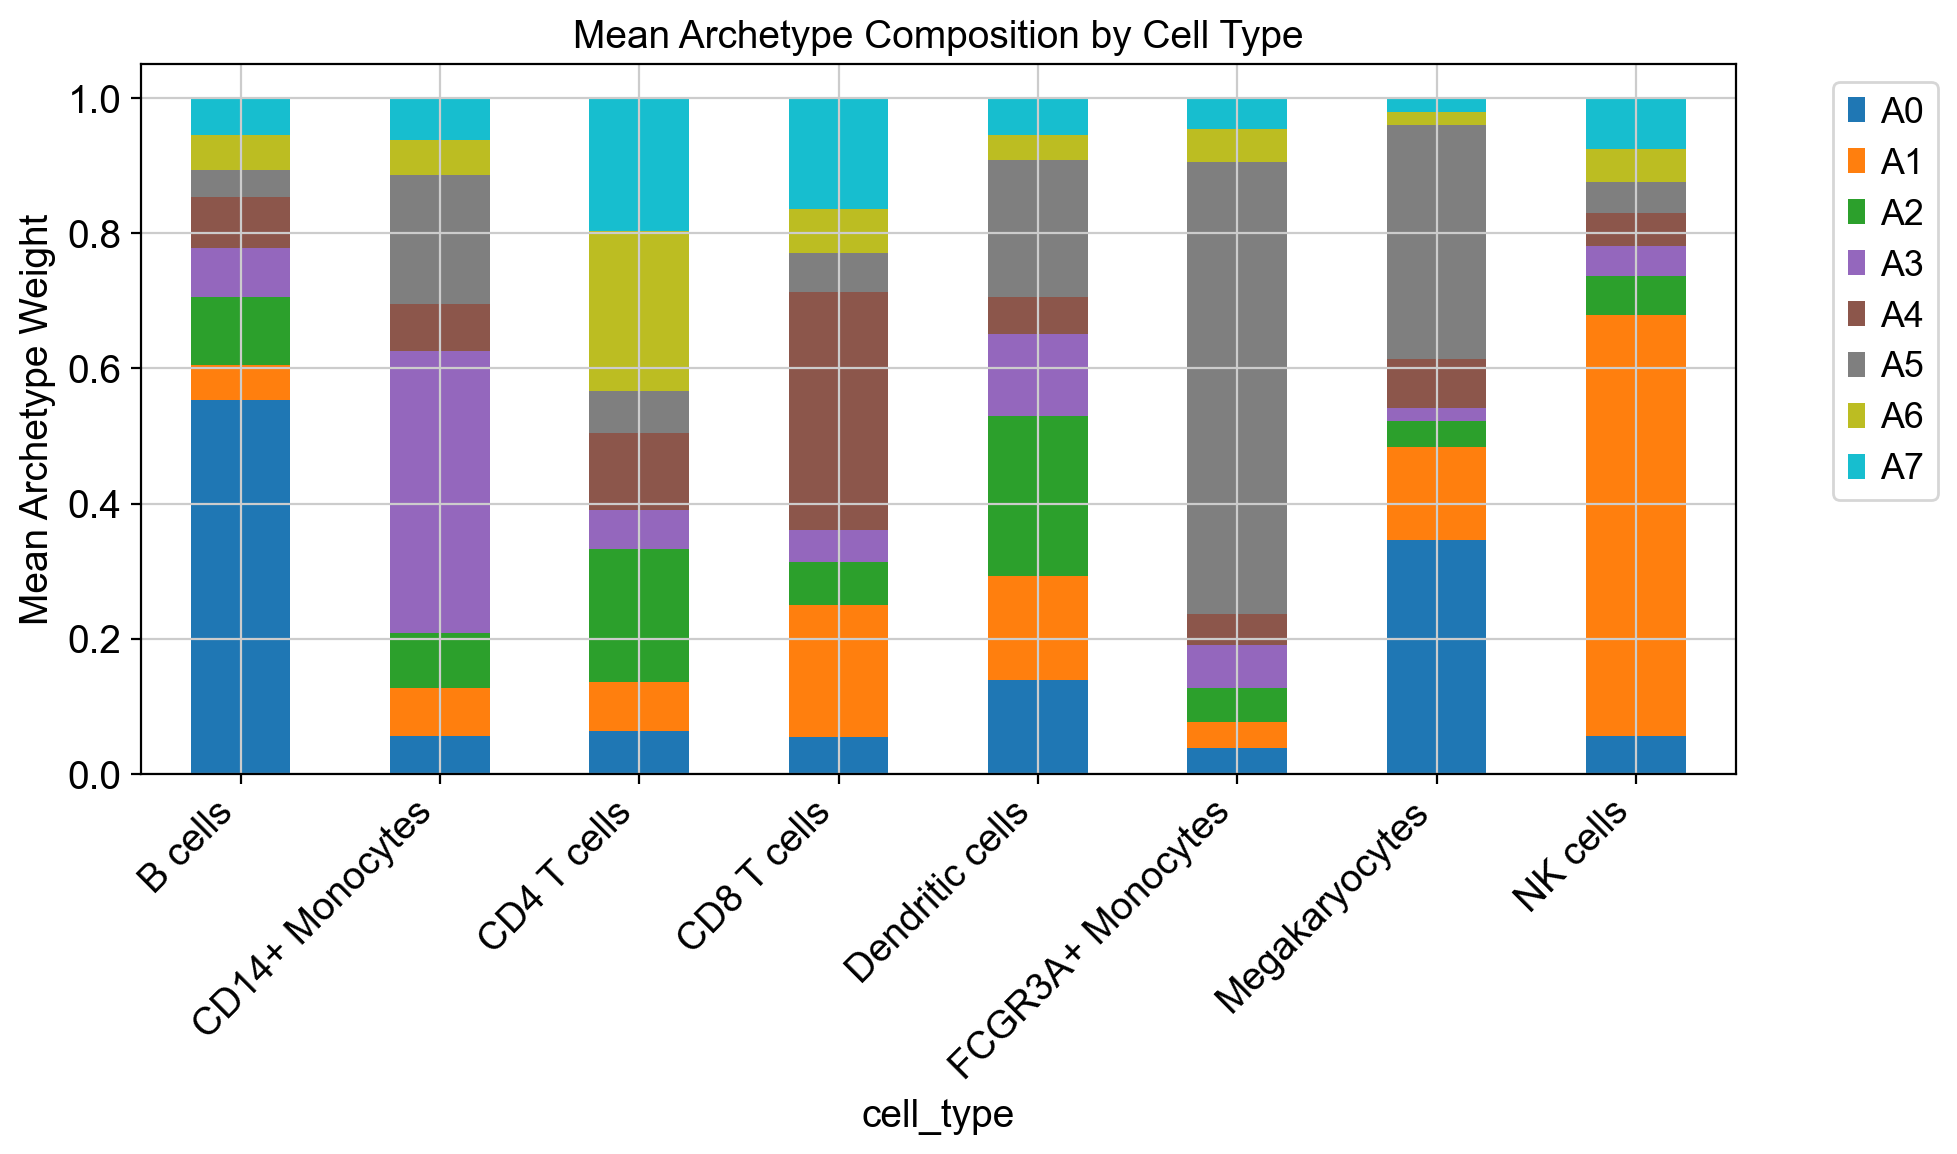

各细胞类型的平均 archetype 权重:
                      A0     A1     A2     A3     A4     A5     A6     A7
cell_type                                                                
B cells            0.553  0.052  0.101  0.072  0.076  0.041  0.052  0.054
CD14+ Monocytes    0.056  0.070  0.082  0.417  0.070  0.191  0.052  0.062
CD4 T cells        0.064  0.072  0.198  0.057  0.114  0.061  0.238  0.196
CD8 T cells        0.055  0.195  0.064  0.048  0.351  0.059  0.064  0.165
Dendritic cells    0.139  0.154  0.236  0.120  0.055  0.203  0.038  0.055
FCGR3A+ Monocytes  0.039  0.038  0.050  0.064  0.045  0.670  0.048  0.046
Megakaryocytes     0.346  0.139  0.038  0.019  0.072  0.346  0.019  0.021
NK cells           0.056  0.623  0.058  0.043  0.049  0.047  0.048  0.076


In [13]:
import pandas as pd

# 每种细胞类型在各 archetype 上的平均权重
df_weights = pd.DataFrame(z, columns=[f"A{i}" for i in range(n_archetypes)])
df_weights["cell_type"] = cell_types

mean_weights = df_weights.groupby("cell_type").mean()

fig, ax = plt.subplots(figsize=(10, 6))
mean_weights.plot(kind="bar", stacked=True, ax=ax, colormap="tab10")
ax.set_ylabel("Mean Archetype Weight")
ax.set_title("Mean Archetype Composition by Cell Type")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("各细胞类型的平均 archetype 权重:")
print(mean_weights.round(3).to_string())

### 6.2 Dominant Archetype 分布

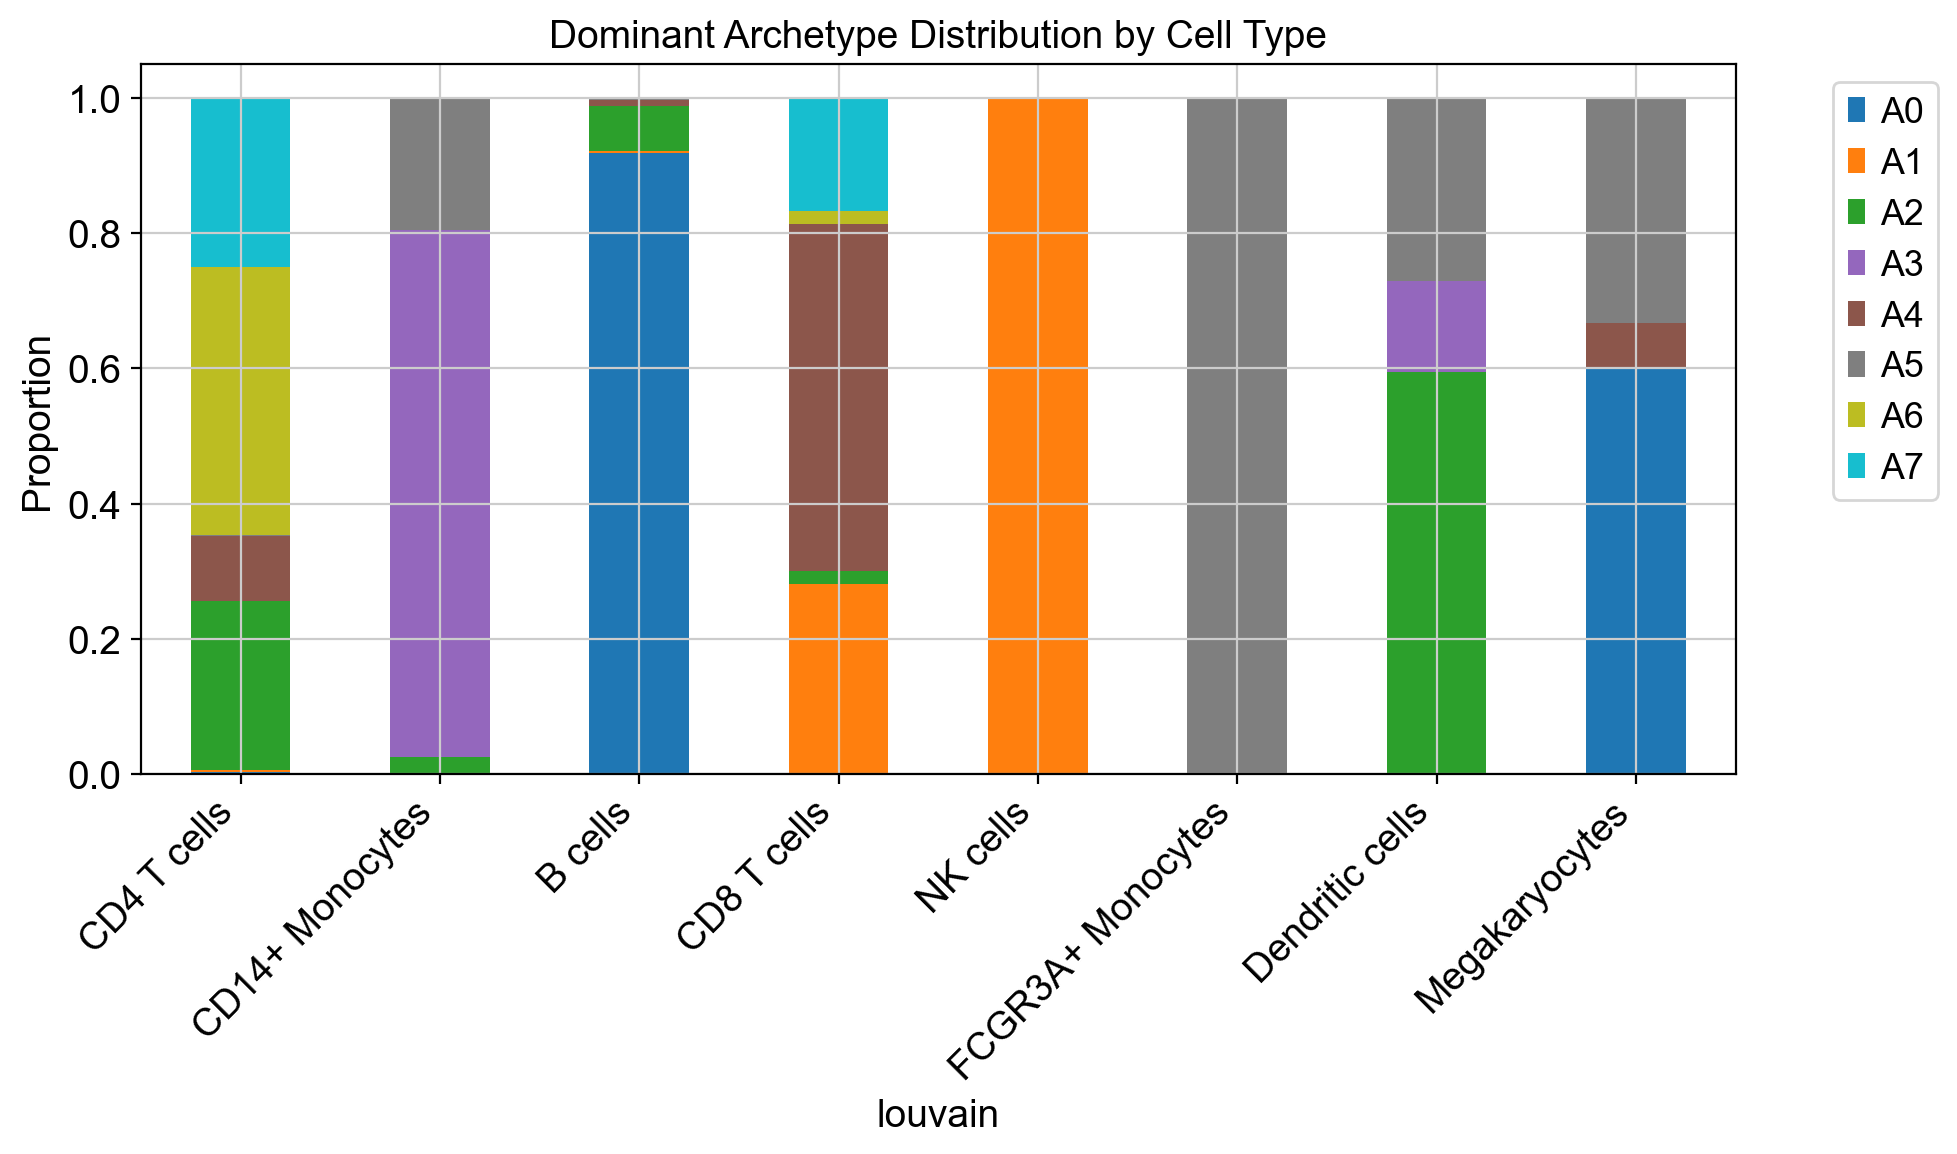

In [14]:
# 交叉表: 细胞类型 vs dominant archetype
ct = pd.crosstab(
    adata_hvg.obs["louvain"],
    adata_hvg.obs["dominant_archetype"],
    normalize="index",
)

fig, ax = plt.subplots(figsize=(10, 6))
ct.plot(kind="bar", stacked=True, ax=ax, colormap="tab10")
ax.set_ylabel("Proportion")
ax.set_title("Dominant Archetype Distribution by Cell Type")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 6.3 Archetype 纯度

衡量每个细胞的 archetype 权重分布有多"尖锐"——纯度越高说明细胞越接近某个 archetype。

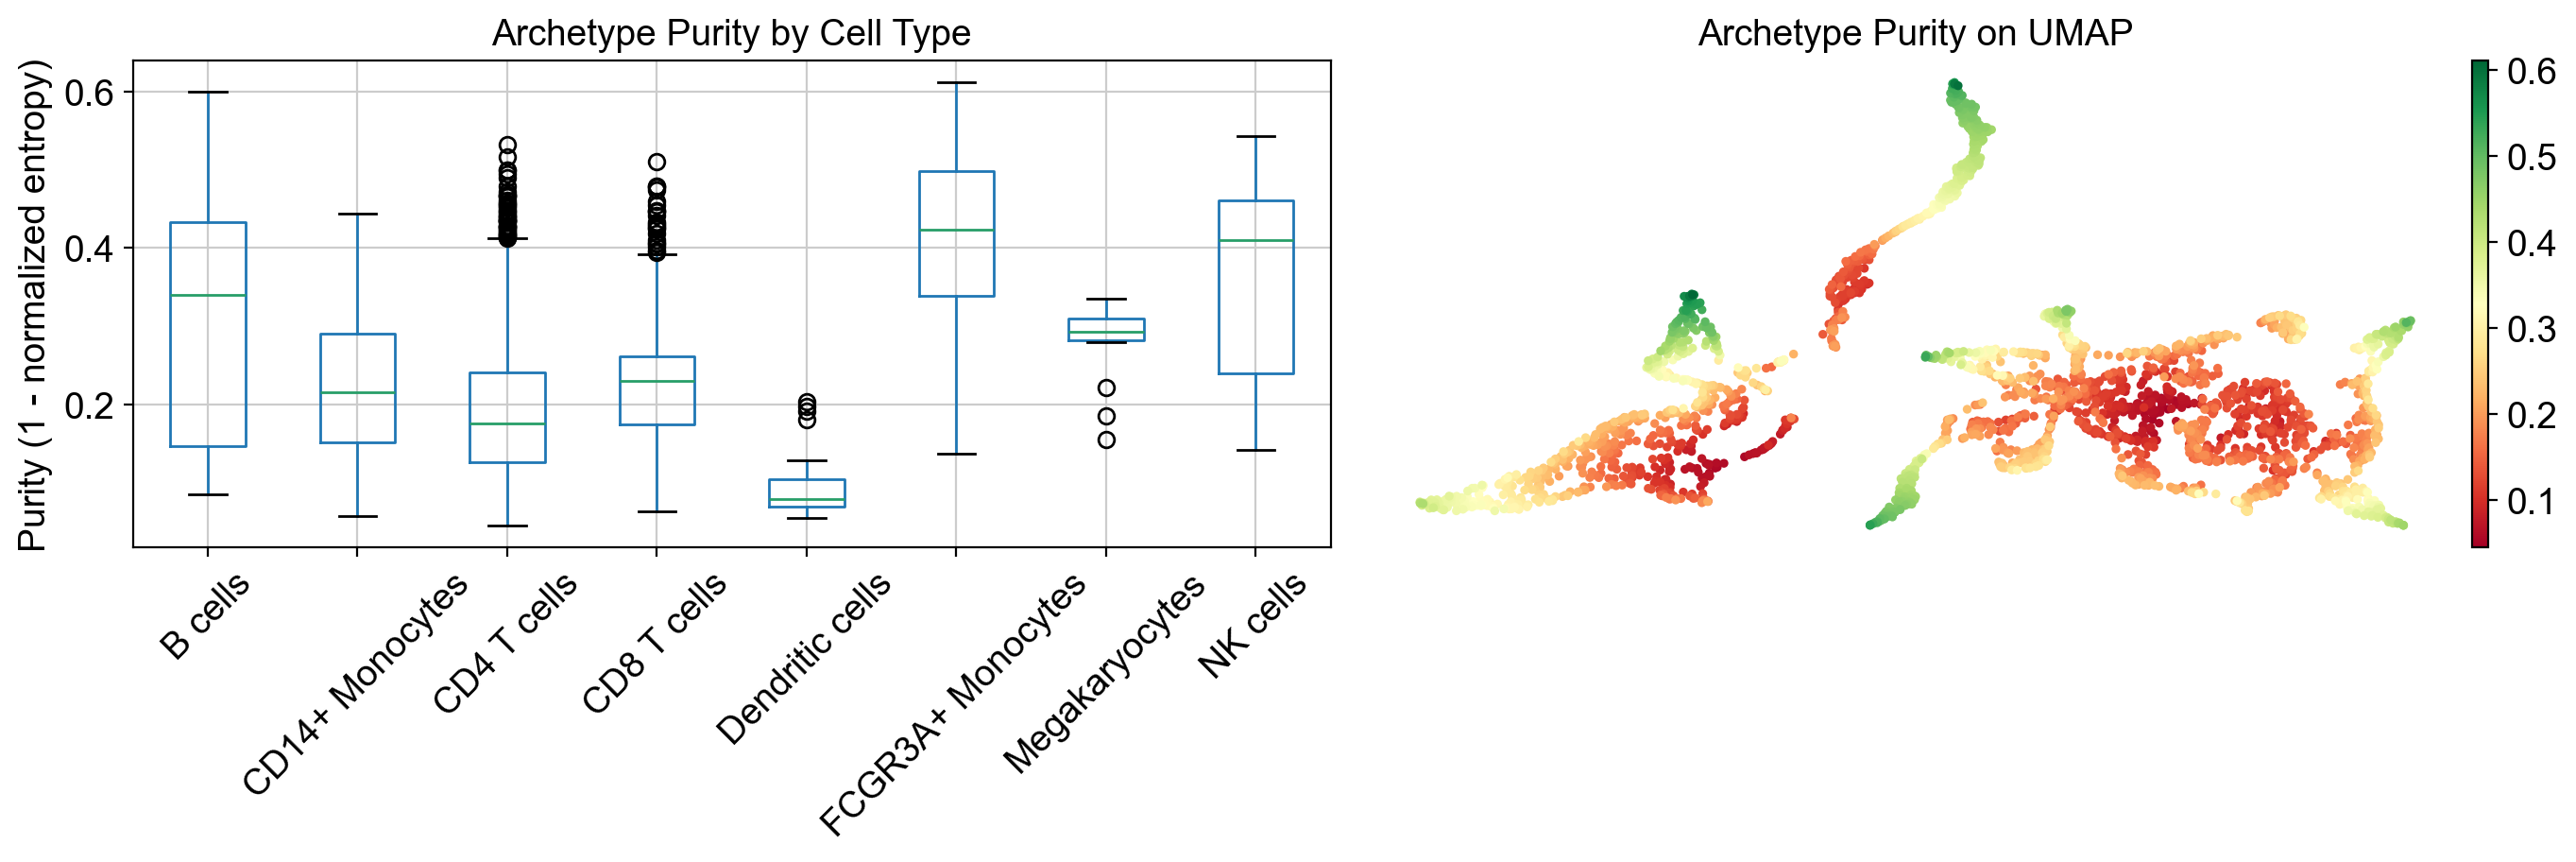

平均纯度: 0.241
纯度范围: [0.045, 0.611]


In [15]:
from scipy.stats import entropy

# 每个细胞的 archetype 权重熵（越低越纯）
cell_entropy = np.array([entropy(z[i]) for i in range(z.shape[0])])
max_entropy = np.log(n_archetypes)
purity = 1 - cell_entropy / max_entropy  # 归一化到 [0, 1]

adata_hvg.obs["archetype_purity"] = purity

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 按细胞类型的纯度分布
purity_by_type = pd.DataFrame({"purity": purity, "cell_type": cell_types})
purity_by_type.boxplot(column="purity", by="cell_type", ax=axes[0], rot=45)
axes[0].set_title("Archetype Purity by Cell Type")
axes[0].set_xlabel("")
axes[0].set_ylabel("Purity (1 - normalized entropy)")
fig.suptitle("")

# UMAP 上着色纯度
sc.pl.umap(adata_hvg, color="archetype_purity", ax=axes[1], show=False,
           title="Archetype Purity on UMAP", color_map="RdYlGn")

plt.tight_layout()
plt.show()

print(f"平均纯度: {purity.mean():.3f}")
print(f"纯度范围: [{purity.min():.3f}, {purity.max():.3f}]")

## 总结

本 notebook 展示了 scDeoxys 在 PBMC 3k 真实数据上的应用：

- ParetoVAE 将每个细胞映射到 K 维 simplex 上，表示为 K 个 archetype 的凸组合
- 通过 archetype 权重可以揭示细胞类型的组成结构和过渡状态
- 高纯度细胞对应明确的细胞类型，低纯度细胞可能处于过渡态或混合状态